# COMSOL transmon capacitance and field

::::{admonition} Required extras
:class: tip

This notebook needs the `comsol` extra:

```bash
uv add "qpdk[comsol]"          # or: pip install "qpdk[comsol]"
uv sync --extra comsol         # from a checkout of this repository
```

Installing the extra installs `MPh`, the Python client for COMSOL, and nothing
else. **It does not install COMSOL and it does not grant a license.** Running
the model build and the electrostatic solve needs a local COMSOL installation
and a license. Google Colab has neither, so the build cells cannot run there.

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

This notebook extracts the two capacitor pads of a QPDK double-pad transmon,
builds a COMSOL sheet model around them, solves the electrostatic problem, and
reads back the pad capacitance and stored energy.

## How this page is published

The figures and numbers on this page are **saved cell outputs**. The numerical
data comes from licensed COMSOL solves; the plotting cells were rerun against
those exports and saved in the committed notebook. The documentation renders
that copy rather than running the cells again.

The whole path is scripted, so a licensed machine reproduces it end to end by
setting `RUN_COMSOL = True`. Without a license the notebook still runs from top
to bottom: the COMSOL cells are skipped, and every cell that reads results
prints how to supply them instead of plotting. On a fresh machine with neither
a license nor exported results you will therefore see the stored figures in the
documentation, but a local run prints skip messages rather than plots. To
replot locally, either export the files with `RUN_COMSOL = True`, or set
`RESULTS_DIR` to a directory that already holds an exported copy.

## What is being modelled

The device is a QPDK
{py:func}`~qpdk.cells.transmon.double_pad_transmon_with_bbox`: two rectangular
capacitor pads separated by a small gap, with a SQUID loop at the centre. The
pads dominate the total capacitance $C$, and the SQUID supplies the Josephson
energy $E_J$, so the qubit transition frequency is set by $E_J$ and the
charging energy $E_C = e^2 / 2C$ {cite:p}`kochChargeinsensitiveQubitDesign2007a`.

In the real device the pads are joined **only** through the Josephson
junction. The QPDK cell draws the SQUID's leads and contact patches on
`JJ_AREA` and `JJ_PATCH`, and those oxide barriers are not metal shorts. The
extraction here works on an **EM-only copy** with those two layers removed, so
the SQUID loop and its leads are not part of the solved geometry and their
parasitic inductance and capacitance are omitted. What remains is the two pads
and the surrounding ground plane, which is exactly what the pad capacitance
needs.

## What the solve is, and what it is not

The physics added is **Electrostatics**, not electromagnetic waves:

- The left pad is driven by a voltage terminal, and the right pad and the
  ground plane are held at ground.
- The solve returns `es.C11`, the capacitance of the driven pad to the grounded
  rest of the chip, and `es.intWe`, the stored electric energy. The two agree,
  since $2 W_e / V^2 = C_{11}$, the standard relation between the energy stored
  in the field and the capacitance of the conductors {cite:p}`m.pozarMicrowaveEngineering2012`.

This is a **quasi-static capacitance extraction**. It says nothing about a
resonance, because there is no resonant element in the model: no Josephson
inductance is present, and the metal is a perfect conductor.

The cells below run this pipeline, in this order:

::::{only} html
```{mermaid}
flowchart TB
    A["Transmon cell:<br>two pads with a SQUID loop"]
    B["EM-only copy:<br>JJ_AREA and JJ_PATCH removed"]
    C["Extracted layout:<br>two pad polygons and the ground plane"]
    D["Sheet model:<br>air above, silicon below, metal faces at z = 0"]
    E["Electrostatics:<br>voltage terminal on the left pad,<br>ground on the right pad and the chip ground"]
    F["Mesh and stationary study"]
    G["Results:<br>es.C11, es.intWe, and the V and es.normE export"]
    A --> B --> C --> D --> E --> F --> G
```
::::

::::{only} typst or typstpdf
The pipeline: the transmon cell, then an EM-only copy with `JJ_AREA` and
`JJ_PATCH` removed, then the extracted layout of two pad polygons and the
ground plane, then the sheet model with air above and silicon below, then an
Electrostatics interface with a voltage terminal on the left pad and ground on
the right pad and the chip ground, then the mesh and a stationary study, then
the capacitance, energy, and field results.
::::

### The LC frequency is an estimate, not an eigenmode

Given $C_{11}$ one can pick a Josephson inductance $L_J$ and form
$f_{LC} = 1 / (2 \pi \sqrt{L_J C_{11}})$. That number is an **estimate**: it uses
an inductance that is not in the COMSOL model, and it is neither a COMSOL
eigenfrequency nor the transmon $f_{01}$. A transmon is an anharmonic oscillator
whose spectrum follows from $E_J$ and $E_C$ treated as a quantum circuit, not
from a single linear LC resonance {cite:p}`blaisCircuitQuantumElectrodynamics2021`,
so the true $f_{01}$ also carries the $E_C$ anharmonic correction. QPDK's
scQubits notebook and {cite:p}`groszkowskiScqubitsPythonPackage2021` provide that
treatment. The value below is labelled an estimate wherever it appears.

::::{admonition} Reading the numbers on this page
:class: warning

The capacitance and energy come from the licensed electrostatic solves below,
but they are not a validated device prediction. The metal is a perfect
conductor, the SQUID loop and leads are absent, and $C_{11}$ is a one-terminal
value rather than the two-pad differential capacitance that sets $E_C$. The
convergence plots show how the value changes with mesh refinement.
::::

**References:**
- QPDK transmon physics and the double-pad cell: {py:func}`~qpdk.cells.transmon.double_pad_transmon_with_bbox`
- [COMSOL Electrostatics interface](https://doc.comsol.com/6.3/doc/com.comsol.help.acdc/acdc_ug_electric_fields.07.002.html)
- [COMSOL capacitance example](https://doc.comsol.com/6.3/doc/com.comsol.help.models.acdc.capacitor_dc/capacitor_dc.html)
- [COMSOL Reference Manual: Analyzing Model Convergence and Accuracy](https://doc.comsol.com/6.3/doc/com.comsol.help.comsol/comsol_ref_modeling.19.043.html)
- [MPh tutorial](https://mph.readthedocs.io/en/stable/tutorial.html)

## Setup and imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[comsol] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])
    print(
        "Note: this installs the Python client only. COMSOL itself and its "
        "license are not pip-installable, so the build and solve cells below "
        "cannot run in Colab, and the result cells will report that no exported "
        "results are present."
    )

In [2]:
import json
from operator import itemgetter
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import axes as mpl_axes, font_manager
from matplotlib.colors import LogNorm
from matplotlib.patches import Polygon as MplPolygon

from qpdk import PDK
from qpdk.cells.transmon import double_pad_transmon_with_bbox
from qpdk.config import PATH
from qpdk.simulation import (
    add_qubit_capacitance_study,
    build_comsol_sheet_model,
    prepare_comsol_layout,
)
from qpdk.tech import LAYER

try:
    import mph
except ImportError:
    mph = None

PDK.activate()

MPH_AVAILABLE = mph is not None


def _outfit_titles() -> None:
    """Draw plot titles in Outfit bold, matching the documentation headings."""
    original_set_title = mpl_axes.Axes.set_title

    def _set_title(self: mpl_axes.Axes, *args: Any, **kwargs: Any) -> Any:
        kwargs.setdefault("fontfamily", "Outfit")
        kwargs.setdefault("fontweight", "bold")
        return original_set_title(self, *args, **kwargs)

    mpl_axes.Axes.set_title = _set_title


def apply_qpdk_style() -> str:
    """Apply the QPDK plot style, falling back to matplotlib's own defaults.

    The style is ``docs/qpdk.mplstyle`` in a checkout and the installed ``qpdk``
    style in a documentation environment; a downloaded notebook outside both
    keeps matplotlib's defaults instead of failing. The documentation fonts are
    used when they are installed, and matplotlib's bundled families otherwise.

    Returns:
        A short description of the style that was applied.
    """
    for source in (PATH.repo / "docs" / "qpdk.mplstyle", "qpdk"):
        try:
            plt.style.use(source)
        except OSError:
            continue
        applied = str(source)
        break
    else:
        applied = "matplotlib defaults"

    installed = {font.name for font in font_manager.fontManager.ttflist}
    plt.rcParams["font.sans-serif"] = [
        name
        for name in ("Inter", "Outfit", "DejaVu Sans", "Helvetica", "Arial")
        if name in installed
    ] + ["sans-serif"]
    if "Outfit" in installed:
        _outfit_titles()
    return applied


def result_file(name: str) -> Path | None:
    """Return the path of an exported solver result, if one is available.

    Args:
        name: File name to look for inside ``RESULTS_DIR``.

    Returns:
        The path, or ``None`` when ``RESULTS_DIR`` is unset or holds no such file.
    """
    if RESULTS_DIR is None:
        return None
    path = RESULTS_DIR / name
    return path if path.exists() else None


def explain_missing_results(name: str) -> None:
    """Print how to supply a result file that is not on disk.

    Args:
        name: File name that was looked for inside ``RESULTS_DIR``.
    """
    print(
        f"No {name} in RESULTS_DIR ({RESULTS_DIR}). The figures on the "
        "documentation page are saved outputs of a licensed solve, and the cells "
        "here replot only from files on disk. To supply them, run with "
        "RUN_COMSOL = True on a licensed machine, which exports into MODEL_DIR, "
        "or set RESULTS_DIR to a directory that already holds an exported "
        f"{name}."
    )


STYLE_SOURCE = apply_qpdk_style()
print("Plot style: QPDK" if STYLE_SOURCE != "matplotlib defaults" else STYLE_SOURCE)

Plot style: QPDK


## Build the transmon cell and an EM-only copy

`prepare_comsol_layout` rejects components carrying geometry on layers it does
not model, and the junction layers are among those. The simplification is made
explicit here: the cell is copied and `JJ_AREA` and `JJ_PATCH` are removed, so
only `M1_DRAW` and the `M1_ETCH` mask it is inverted from remain.

In [3]:
component = double_pad_transmon_with_bbox(bbox_extension=200.0)

junction_port = component.ports["junction"]
JUNCTION_CENTER_UM = tuple(junction_port.center)

em_component = component.copy()
em_component.remove_layers(layers=[LAYER.JJ_AREA, LAYER.JJ_PATCH])

print(f"Component: {component.name}")
print(f"Bounding box (µm): {component.bbox()}")
print(f"Junction site: center={JUNCTION_CENTER_UM} µm")
print(f"Layers kept:   {sorted(em_component.layers)}")
print("JJ_AREA/JJ_PATCH removed; M1_DRAW and M1_ETCH remain.")

Component: double_pad_transmon_with_bbox_BE200_PS250_400_PG15_JSsq_c3fdad3b
Bounding box (µm): (-457.5,-400;457.5,400)
Junction site: center=(0.0, 0.0) µm
Layers kept:   [(1, 0), (1, 1)]
JJ_AREA/JJ_PATCH removed; M1_DRAW and M1_ETCH remain.


## Extract the COMSOL layout

The qubit pads are not transmission-line ports, so the extraction is asked for
no feed ports. The etched moat is a *hole* in the ground-plane polygon; the two
pads sit inside it as separate metal polygons.

In [4]:
layout = prepare_comsol_layout(em_component, feed_ports=None, ground_margin=100.0)

print(f"Metal polygons: {len(layout.polygons)}")
print(f"Feed ports:     {layout.feed_ports}")
print(f"Prepared bbox (µm): {layout.bbox}")

# Three conductor faces: the two pads and the ground plane. Each point below
# sits well inside its metal region so the face selection resolves to exactly
# one face, which the study builder checks before adding the terminals.
LEFT_PAD_POINT = (-132.5, 0.0)
RIGHT_PAD_POINT = (132.5, 0.0)
GROUND_POINT = (-500.0, 0.0)

Metal polygons: 3
Feed ports:     ()
Prepared bbox (µm): ComsolBoundingBox(xmin=-557.5, ymin=-500.0, xmax=557.5, ymax=500.0)


findfont: Failed to find font weight bold, now using 400.


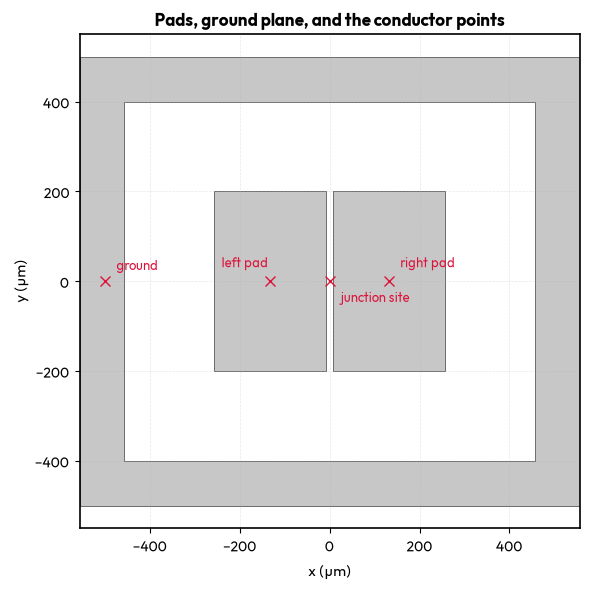

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
for polygon in sorted(
    layout.polygons,
    key=lambda item: (
        -(
            (max(x for x, _ in item.outline) - min(x for x, _ in item.outline))
            * (max(y for _, y in item.outline) - min(y for _, y in item.outline))
        )
    ),
):
    ax.add_patch(
        MplPolygon(
            polygon.outline,
            closed=True,
            facecolor="0.78",
            edgecolor="0.35",
            linewidth=0.6,
            zorder=1,
        )
    )
    for hole in polygon.holes:
        ax.add_patch(
            MplPolygon(
                hole,
                closed=True,
                facecolor="white",
                edgecolor="0.35",
                linewidth=0.6,
                zorder=1,
            )
        )
for point, label, offset in (
    (LEFT_PAD_POINT, "left pad", (-35, 10)),
    (RIGHT_PAD_POINT, "right pad", (8, 10)),
    (GROUND_POINT, "ground", (8, 8)),
    (JUNCTION_CENTER_UM, "junction site", (8, -15)),
):
    ax.plot(*point, marker="x", color="crimson", markersize=7, zorder=4)
    ax.annotate(
        label,
        point,
        textcoords="offset points",
        xytext=offset,
        fontsize=9,
        color="crimson",
    )
ax.set_aspect("equal")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title("Pads, ground plane, and the conductor points")
plt.tight_layout()
plt.show()

## Build the COMSOL model and capacitance study

Two calls configure the model:

- {py:func}`~qpdk.simulation.comsol_sheet.build_comsol_sheet_model` creates the
  air and silicon blocks meeting at $z = 0$, imprints the layout metal on that
  interface as faces, and assigns materials ($\epsilon_r = 1$ air,
  $\epsilon_r = 11.7$ silicon).
- {py:func}`~qpdk.simulation.comsol_capacitance.add_qubit_capacitance_study`
  picks the two pad faces and the ground face with the points above, drives the
  left pad with a voltage terminal, grounds the right pad and the ground plane,
  and adds the mesh and a stationary study. The selection builder refuses a
  point that does not land on exactly one face, so a wrong point fails loudly
  instead of grounding the wrong area.

`mph.start(cores=...)` launches a local COMSOL process and attaches to it.
Only one MPh client can exist per Python process, and the call needs a COMSOL
installation and a license. The block is off by default so the notebook runs
without one; set `RUN_COMSOL = True` on a licensed machine to build, solve, and
save the model.

`RUN_MESH_STUDY` turns on the mesh convergence series further down this page.
That series builds and solves one fresh model per mesh size, so it needs
`RUN_COMSOL = True` for the client and it costs a full build and solve per
size. It is off by default.

`RUN_LOCAL_REFINEMENT` turns on a second series further down: the same
automatic size as a base, with a localized refinement of the metal plane
stacked on top. It is a separate control from the automatic size, it also needs
`RUN_COMSOL = True`, and it costs a build and solve per pass. It is off by
default.

`RESULTS_DIR` is where the cells that read results look for exported files. It
defaults to `None` so that a run without a license skips those cells, and to
`MODEL_DIR` when `RUN_COMSOL` is `True`, because the licensed branch below
exports into `MODEL_DIR`. Point it at any directory of exported files to replot
an existing run without starting COMSOL, for example
`RESULTS_DIR = Path("exports")`.

In [6]:
RUN_COMSOL = False
RUN_MESH_STUDY = False  # mesh convergence series below; needs RUN_COMSOL
RUN_LOCAL_REFINEMENT = False  # localized metal-plane refine series; needs RUN_COMSOL
MODEL_DIR = Path.home() / "comsol_models"
MODEL_PATH = MODEL_DIR / "comsol_qubit_capacitance.mph"
RESULTS_DIR: Path | None = MODEL_DIR if RUN_COMSOL else None
CORES = 4
VOLTAGE_V = 1.0

model = None
if RUN_COMSOL and not MPH_AVAILABLE:
    raise RuntimeError("RUN_COMSOL needs MPh and a licensed COMSOL installation")

if RUN_COMSOL and MPH_AVAILABLE:
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    client = mph.start(cores=CORES)
    model = build_comsol_sheet_model(
        client,
        layout,
        name="QPDK Double-Pad Transmon",
        substrate_thickness_um=200.0,
        air_height_um=200.0,
    )
    add_qubit_capacitance_study(
        model,
        layout,
        left_pad_point=LEFT_PAD_POINT,
        right_pad_point=RIGHT_PAD_POINT,
        ground_point=GROUND_POINT,
        voltage_v=VOLTAGE_V,
        mesh_size=1,
    )
    model.java.component("comp1").mesh("mesh1").run()
    model.java.study("std1").run()
    model.save(MODEL_PATH)

    capacitance_f = float(model.evaluate("es.C11"))
    stored_energy_j = float(model.evaluate("es.intWe"))
    print(f"es.C11 = {capacitance_f:.6e} F")
    print(f"es.intWe = {stored_energy_j:.6e} J")
    print(f"2*intWe/V^2 = {2.0 * stored_energy_j / VOLTAGE_V**2:.6e} F")
    print(f"Saved model to {MODEL_PATH}")

    metrics_path = MODEL_DIR / "comsol_qubit_metrics.json"
    metrics_path.write_text(
        json.dumps(
            {
                "capacitance_f": capacitance_f,
                "stored_energy_j": stored_energy_j,
                "voltage_v": VOLTAGE_V,
                "solver": "COMSOL Multiphysics",
                "study": "Electrostatics stationary",
                "mesh_size": 1,
                "substrate_thickness_um": 200.0,
                "air_height_um": 200.0,
                "silicon_relative_permittivity": 11.7,
            },
            indent=2,
        )
        + "\n"
    )

### Exporting the potential and field map

The potential and field map shown further down this page was written from the
solved model with COMSOL's Data export on a cut plane at $z = 1$ µm, carrying
the potential $V$ and the field norm `es.normE`. The same export is scripted
below: a `CutPlane` dataset over the $xy$ plane, then a `Data` result export
listing both expressions. It runs inside the licensed branch, next to the
solve, and writes into `MODEL_DIR`, where `RESULTS_DIR` picks it up.

In [7]:
if RUN_COMSOL and MPH_AVAILABLE and model is not None:
    plane = model.java.result().dataset().create("cutplane", "CutPlane")
    plane.set("planetype", "quick")
    plane.set("quickplane", "xy")
    plane.set("quickz", "1[um]")
    plane.set("data", "dset1")

    field_export = model.java.result().export().create("field", "Data")
    field_export.set("data", "cutplane")
    field_export.set("expr", ["V", "es.normE"])
    field_export.set("filename", str(MODEL_DIR / "comsol_qubit_field.txt"))
    field_export.run()
    print(f"Exported V and es.normE to {MODEL_DIR / 'comsol_qubit_field.txt'}")

## Saved capacitance result

This cell replots the exported metrics from the electrostatic solve above.
`C11` is the capacitance of the driven pad to the grounded rest of the chip,
and the stored energy is checked against it through $2 W_e / V^2$. This
one-terminal $C_{11}$ does not by itself give the differential-mode capacitance
of the two floating pads, so it is not yet the transmon charging capacitance.

With `RESULTS_DIR` unset, or set to a directory without the export, the cell
prints how to supply the file instead of a result.

In [8]:
METRICS_JSON = "comsol_qubit_metrics.json"
metrics_file = result_file(METRICS_JSON)

capacitance_f: float | None = None
stored_energy_j: float | None = None
voltage_v: float | None = None

if metrics_file is None:
    explain_missing_results(METRICS_JSON)
else:
    metrics = json.loads(metrics_file.read_text())
    capacitance_f = float(metrics["capacitance_f"])
    stored_energy_j = float(metrics["stored_energy_j"])
    voltage_v = float(metrics["voltage_v"])

    capacitance_from_energy_f = 2.0 * stored_energy_j / voltage_v**2
    print(f"es.C11                       = {capacitance_f:.6e} F")
    print(f"2 * es.intWe / V^2           = {capacitance_from_energy_f:.6e} F")
    print(
        "relative difference          = "
        f"{abs(capacitance_from_energy_f - capacitance_f) / capacitance_f:.2e}"
    )
    for key in ("solver", "study", "mesh_size"):
        if (value := metrics.get(key)) is not None:
            print(f"{key:<28} = {value}")

es.C11                       = 1.183085e-13 F
2 * es.intWe / V^2           = 1.183085e-13 F
relative difference          = 6.40e-16
solver                       = COMSOL Multiphysics 6.3
study                        = Electrostatics stationary
mesh_size                    = 1


### An LC frequency estimate

With $C_{11}$ in hand, a Josephson inductance $L_J$ gives a rough scale for the
circuit frequency. **$L_J$ is not part of the COMSOL solve**, and $C_{11}$ is
not the two-pad differential capacitance. The resulting number only shows the
scale one would get from these illustrative circuit values; it is not an
eigenfrequency or the transmon $f_{01}$.

In [9]:
LJ_H = 10e-9  # chosen, not solved for

if capacitance_f is None:
    print(f"Skipping the estimate: no {METRICS_JSON} available (see the note above).")
else:
    f_lc_ghz = 1.0 / (2.0 * np.pi * np.sqrt(LJ_H * capacitance_f)) / 1e9
    print(f"Chosen L_J                    = {LJ_H * 1e9:.1f} nH")
    print(f"illustrative f_LC using C11     = {f_lc_ghz:.3f} GHz")
    print("L_J is not in the model; C11 is not the differential pad capacitance.")

Chosen L_J                    = 10.0 nH
illustrative f_LC using C11     = 4.627 GHz
L_J is not in the model; C11 is not the differential pad capacitance.


## Saved potential and field map

The exported field is the potential $V$ and the electric-field norm on the
$z = 1$ µm plane. The metal sheet lies at $z = 0$ and the plane sits just above
it, so the map shows the potential holding across the driven pad and the field
concentrating in the pad gap and along the pad edges. This baseline map uses
automatic mesh size 1; a separately refined map appears below.

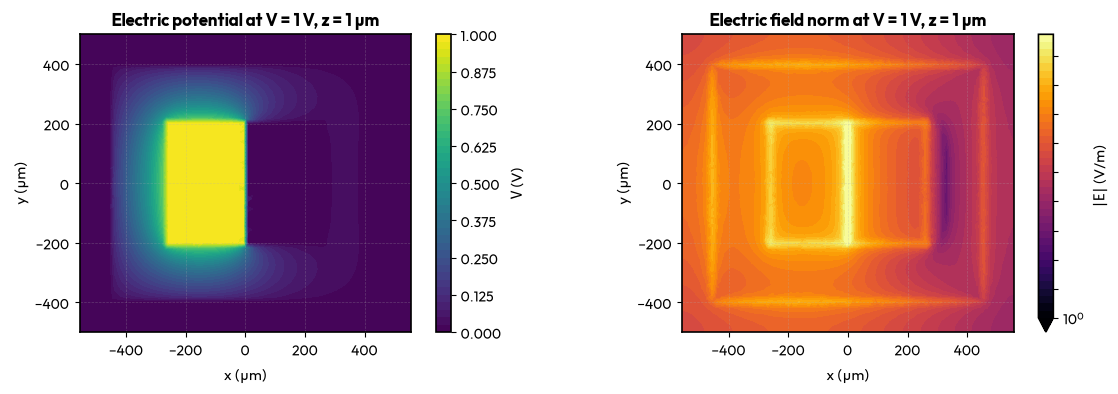

In [10]:
FIELD_TXT = "comsol_qubit_field.txt"
field_file = result_file(FIELD_TXT)

if field_file is None:
    explain_missing_results(FIELD_TXT)
else:
    field = np.loadtxt(field_file, comments="%")
    field_x, field_y = field[:, 0], field[:, 1]
    field_v, field_e = field[:, 3], field[:, 4]

    voltage_label = f"at V = {voltage_v:g} V, " if voltage_v is not None else ""

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    potential = axes[0].tricontourf(
        field_x, field_y, field_v, levels=40, cmap="viridis"
    )
    axes[0].set_title(f"Electric potential {voltage_label}z = 1 µm")
    fig.colorbar(potential, ax=axes[0], label=r"$V$ (V)")

    norm_e = axes[1].tricontourf(
        field_x,
        field_y,
        field_e,
        levels=np.geomspace(1.0, field_e.max(), 40),
        norm=LogNorm(vmin=1.0, vmax=field_e.max()),
        cmap="inferno",
        extend="min",
    )
    axes[1].set_title(f"Electric field norm {voltage_label}z = 1 µm")
    fig.colorbar(norm_e, ax=axes[1], label=r"$|\mathbf{E}|$ (V/m)")

    for axis in axes:
        axis.set_aspect("equal")
        axis.set_xlabel("x (µm)")
        axis.set_ylabel("y (µm)")
    plt.tight_layout()
    plt.show()

The potential is near its terminal value over the driven pad and falls to zero
across the gap to the grounded pad and ground plane. The field is concentrated
in that gap and at the pad edges, which is where the pad capacitance mainly
lives, and it is why the mesh has to resolve the gap and the metal edges for
the capacitance to converge.

## Mesh convergence study

A mesh convergence study re-solves one and the same model with everything held
fixed except the element size, and watches how the quantity of interest moves
as the mesh is refined. That is the only evidence a discretised number is set
by the physics rather than by the mesh, and COMSOL's own guidance on running
and reading one is in
[Analyzing Model Convergence and Accuracy](https://doc.comsol.com/6.3/doc/com.comsol.help.comsol/comsol_ref_modeling.19.043.html).

The series below varies `mesh_size` alone, from 7 down to 1, and builds a fresh
model for every size. The layout, the air and silicon thicknesses, the three
conductor points, and the 1 V terminal are the same arguments the solve above
uses, so the mesh is the only thing that changes. Each row records the 3D
element count from `getNumElem`, the one-terminal capacitance `es.C11`, and the
stored energy `es.intWe`.

### What a converged capacitance does and does not establish

If $C_{11}$ stops moving as the element count grows, then this one-terminal
capacitance for this geometry is no longer mesh-limited. That is all it
establishes. A **converged $C_{11}$ does not prove** that the peak field at the
pad edges has converged, that the influence of the outer domain boundary has
gone away, or that the mesh would still be adequate for a different quantity
such as a differential capacitance or a resonant frequency. The peak field is a
local maximum that grows as the gap is resolved even while the integral behind
$C_{11}$ is flat; the outer walls and the extent of the ground plane are fixed
geometry, so refining the mesh cannot remove their effect on $C_{11}$ and only
a change of domain size can; and a different quantity on the same mesh is a
different convergence question.

$C_{11}$ and $2 W_e / V^2$ agreeing is **not** evidence of convergence either.
It is an internal consistency check: the solver reports the same field twice,
once as a terminal capacitance and once as a stored energy, so the two must
agree whatever the mesh is. It checks that the two exported quantities are
consistent; it cannot verify the terminal selection or resolve an under-meshed gap.

The series is off by default. Set `RUN_MESH_STUDY = True` alongside
`RUN_COMSOL = True`; it reuses the client the licensed branch already started,
because only one MPh client can exist per Python process. A mesh size that
fails to mesh or solve is printed in full and left out of the table, so a gap
in the series is visible rather than silently dropped. The JSON holds the rows
and the sizes that failed, nothing else.

In [11]:
QUBIT_MESH_SIZES = (7, 6, 5, 4, 3, 2, 1)
MESH_JSON = "comsol_mesh_convergence.json"
MESH_KEY = "qubit_mesh_convergence"


def mesh_element_count(model: Any) -> int:
    """Return the number of mesh elements in a model's mesh.

    Args:
        model: A built and meshed MPh model.

    Returns:
        The number of mesh elements.
    """
    return int(model.java.component("comp1").mesh("mesh1").getNumElem())


def run_qubit_mesh_size(client: Any, size: int) -> dict[str, Any]:
    """Build, mesh, and solve one mesh size, and return its convergence row.

    The model is built from scratch so nothing carries over from another size,
    and it is removed from the client even when the mesh or the solve raises.

    Args:
        client: The MPh client the licensed branch already started.
        size: COMSOL mesh size, 1 (finest) to 9 (coarsest).

    Returns:
        A row holding the mesh size, the mesh element count, ``es.C11`` in
        farads, and ``es.intWe`` in joules at ``VOLTAGE_V``.
    """
    temp_model = build_comsol_sheet_model(
        client,
        layout,
        name=f"QPDK transmon mesh size {size}",
        substrate_thickness_um=200.0,
        air_height_um=200.0,
    )
    try:
        add_qubit_capacitance_study(
            temp_model,
            layout,
            left_pad_point=LEFT_PAD_POINT,
            right_pad_point=RIGHT_PAD_POINT,
            ground_point=GROUND_POINT,
            voltage_v=VOLTAGE_V,
            mesh_size=size,
        )
        temp_model.java.component("comp1").mesh("mesh1").run()
        element_count = mesh_element_count(temp_model)
        temp_model.java.study("std1").run()
        for problem in temp_model.problems():
            print(f"  mesh size {size} reports: {problem}")
        return {
            "mesh_size": size,
            "voltage_v": VOLTAGE_V,
            "element_count": element_count,
            "c11_f": float(np.atleast_1d(temp_model.evaluate("es.C11"))[0]),
            "int_we_j": float(np.atleast_1d(temp_model.evaluate("es.intWe"))[0]),
        }
    finally:
        client.remove(temp_model)


if RUN_COMSOL and MPH_AVAILABLE and RUN_MESH_STUDY:
    rows: list[dict[str, Any]] = []
    failures: list[dict[str, Any]] = []

    for size in QUBIT_MESH_SIZES:
        print(f"Mesh size {size}: building, meshing, and solving")
        try:
            row = run_qubit_mesh_size(client, size)
        except Exception as error:
            failures.append({"mesh_size": size, "error": type(error).__name__})
            print(f"Mesh size {size} FAILED: {type(error).__name__}: {error}")
            continue
        rows.append(row)
        print(
            f"Mesh size {size}: {row['element_count']} elements, "
            f"C11 = {row['c11_f'] * 1e15:.4f} fF, "
            f"intWe = {row['int_we_j']:.6e} J"
        )

    mesh_path = MODEL_DIR / MESH_JSON
    try:
        mesh_payload = json.loads(mesh_path.read_text())
    except FileNotFoundError:
        mesh_payload = {}
    mesh_payload[MESH_KEY] = rows
    if failures:
        mesh_payload[f"{MESH_KEY}_failures"] = failures
    else:
        mesh_payload.pop(f"{MESH_KEY}_failures", None)
    mesh_path.write_text(json.dumps(mesh_payload, indent=2) + "\n")
    print(f"Wrote {len(rows)} of {len(QUBIT_MESH_SIZES)} rows to {mesh_path}")
    if failures:
        failed_sizes = ", ".join(str(item["mesh_size"]) for item in failures)
        print(f"No row was written for mesh sizes: {failed_sizes}")
elif RUN_MESH_STUDY and not RUN_COMSOL:
    print(
        "RUN_MESH_STUDY needs RUN_COMSOL = True: the series reuses the COMSOL "
        "client that the licensed branch starts."
    )

### Reading the convergence table

The cell below replots those rows: $C_{11}$ in fF against the mesh element count,
each point labelled with its mesh size (1 is the finest mesh, 7 the coarsest),
with the change from one mesh to the next printed underneath. Differences that
shrink as the mesh refines are the shape a settled number makes; differences
that keep their size, or change sign, mean the capacitance is still moving with
the mesh. The table also carries $2 W_e / V^2$ next to $C_{11}$ and their
relative difference: that column is the consistency check described above and
stays flat whatever the mesh does, so it is not read as convergence.

With `RESULTS_DIR` unset, or set to a directory without the file, the cell
prints how to supply it and draws nothing.

mesh   elements   C11 (fF)      dC11  2W/V^2 (fF)  rel. diff
   7       1000   175.1443               175.1443    1.6e-16
   6       2514   131.0901  -44.0541     131.0901    1.5e-15
   5       6098   126.0184   -5.0717     126.0184    1.8e-15
   4      12174   123.5870   -2.4314     123.5870    2.1e-15
   3      31100   122.9890   -0.5980     122.9890    3.5e-16
   2     123126   121.1601   -1.8289     121.1601    2.1e-15
   1     680601   118.3085   -2.8516     118.3085    7.2e-16


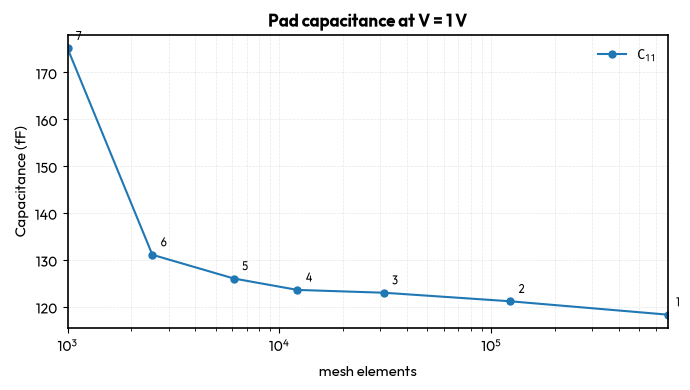

In [12]:
mesh_file = result_file(MESH_JSON)

if mesh_file is None:
    explain_missing_results(MESH_JSON)
else:
    mesh_payload = json.loads(mesh_file.read_text())
    rows = mesh_payload.get(MESH_KEY) or []
    for failure in mesh_payload.get(f"{MESH_KEY}_failures") or []:
        print(f"Mesh size {failure['mesh_size']} failed: {failure['error']}")
    if not rows:
        explain_missing_results(MESH_JSON)
        print(f"The file on disk carries no {MESH_KEY} rows.")
    else:
        rows = sorted(rows, key=itemgetter("element_count"))
        element_counts = np.array([row["element_count"] for row in rows], dtype=float)
        mesh_sizes = [int(row["mesh_size"]) for row in rows]
        capacitance_ff = np.array([row["c11_f"] for row in rows], dtype=float) * 1e15
        energy_ff = (
            np.array([row["int_we_j"] for row in rows], dtype=float)
            * 2.0
            / np.array([row["voltage_v"] for row in rows], dtype=float) ** 2
            * 1e15
        )
        voltages_v = {float(row["voltage_v"]) for row in rows}
        if len(voltages_v) != 1:
            raise ValueError("Mesh rows have different solved voltages")
        solved_voltage_v = voltages_v.pop()

        print(
            f"{'mesh':>4} {'elements':>10} {'C11 (fF)':>10} {'dC11':>9} "
            f"{'2W/V^2 (fF)':>12} {'rel. diff':>10}"
        )
        for index, row in enumerate(rows):
            step = (
                ""
                if index == 0
                else f"{capacitance_ff[index] - capacitance_ff[index - 1]:>+9.4f}"
            )
            relative = (
                abs(energy_ff[index] - capacitance_ff[index]) / capacitance_ff[index]
            )
            print(
                f"{row['mesh_size']:>4} {row['element_count']:>10} "
                f"{capacitance_ff[index]:>10.4f} {step:>9} "
                f"{energy_ff[index]:>12.4f} {relative:>10.1e}"
            )

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(
            element_counts,
            capacitance_ff,
            marker="o",
            markersize=5,
            label=r"$C_{11}$",
        )
        for x, y, size in zip(element_counts, capacitance_ff, mesh_sizes, strict=True):
            ax.annotate(
                str(size),
                (x, y),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=8,
            )
        ax.set_xscale("log")
        ax.set_xlabel("mesh elements")
        ax.set_ylabel("Capacitance (fF)")
        ax.set_title(f"Pad capacitance at V = {solved_voltage_v:g} V")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

### Localized metal-plane refinement

The series above moves one control: COMSOL's overall automatic mesh size, which
scales the element size over the whole model. A second and separate control is
to keep that automatic size as the base and refine only where the field is
known to be concentrated. The series below does that. Each pass is built at
automatic size 2, meshed, and then a refinement feature restricted to a box
around the metal plane is added and the mesh is run again.

**A pass here is a mesh refinement pass, not a solver iteration.** It is one
application of the refinement feature to the mesh. It is not a Newton or other
nonlinear iteration, and nothing about the stationary solver's own convergence
is read from the pass number.

The box spans the whole prepared layout in $x$ and $y$ and runs from
$z = -20$ to $+20$ µm, so it contains the metal sheet, the pad gap, and the pad
edges beside it, where the field concentrates. Each pass refines the elements
whose corners lie inside the box, splitting their longest edge. Elements just
outside can be pulled in by the conforming mesh, so the element count is not
only the elements of the box.

The local refinement and the automatic-size series are **separate controls**,
not two dials on one thing: the automatic size sets the base element size
everywhere, and the refinement changes a subregion of that base. A settled
local-refinement series and a settled automatic-size series are therefore
different statements about the model, and neither one establishes the other.
The caution from the section above carries over unchanged: a settled $C_{11}$
would say that this one-terminal capacitance is no longer mesh-limited, and
nothing more. It would **not** say that the peak field at the pad edges or the
influence of the outer domain boundary had converged.

$C_{11}$ and $2 W_e / V^2$ agreeing on every pass is **not** convergence either.
It is the internal consistency check described above, and it holds whatever the
mesh is, so it is not read as evidence that the mesh is adequate.

Pass 0 is the automatic size 2 mesh with no refinement, the same base the
series above records, so the refined passes are read as a change from it.

The series is off by default. Set `RUN_LOCAL_REFINEMENT = True` alongside
`RUN_COMSOL = True`; it reuses the client the licensed branch already started,
because only one MPh client can exist per Python process. It costs a build, a
mesh, and a solve per pass. A pass that fails to mesh or solve is printed in
full and left out of the table, and the passes that failed are kept in the JSON
next to the rows that were written, so a gap in the series is visible rather
than silently dropped.

In [13]:
LOCAL_BASE_MESH_SIZE = 2
LOCAL_REFINE_PASSES = (0, 1, 2, 3, 4, 5, 6, 7)
LOCAL_BOX_Z_UM = 20.0
LOCAL_MESH_KEY = "qubit_local_refine"


def compact_element_count(count: int) -> str:
    """Format an element count for a plot label.

    Args:
        count: Number of mesh elements.

    Returns:
        The count in thousands, or the plain count below ten thousand.
    """
    return f"{count / 1e3:.0f}k" if count >= 10_000 else f"{count:,}"


def run_qubit_refine_pass(client: Any, passes: int) -> dict[str, Any]:
    """Build, locally refine, and solve one refinement pass.

    The model is built from scratch at ``LOCAL_BASE_MESH_SIZE`` and meshed once,
    so the refinement lays on top of the automatic size instead of replacing it.
    The model is removed from the client even when the mesh or the solve raises.

    Args:
        client: The MPh client the licensed branch already started.
        passes: Number of refinement passes to apply.

    Returns:
        A row holding the pass count, the mesh element count, ``es.C11`` in
        farads, and ``es.intWe`` in joules at ``VOLTAGE_V``.

    Raises:
        RuntimeError: The refined mesh has no mesh elements.
    """
    temp_model = build_comsol_sheet_model(
        client,
        layout,
        name=f"QPDK transmon refine passes {passes}",
        substrate_thickness_um=200.0,
        air_height_um=200.0,
    )
    try:
        add_qubit_capacitance_study(
            temp_model,
            layout,
            left_pad_point=LEFT_PAD_POINT,
            right_pad_point=RIGHT_PAD_POINT,
            ground_point=GROUND_POINT,
            voltage_v=VOLTAGE_V,
            mesh_size=LOCAL_BASE_MESH_SIZE,
        )
        mesh = temp_model.java.component("comp1").mesh("mesh1")
        mesh.run()
        # Refine switches the sequence to user-controlled, so retain a generator.
        mesh.create("ftet_refine", "FreeTet")
        if passes:
            refine = mesh.create("ref1", "Refine")
            refine.set("numrefine", passes)
            refine.set("rmethod", "longest")
            refine.set("boxcoord", "on")
            refine.set("xmin", f"{layout.bbox.xmin}[um]")
            refine.set("xmax", f"{layout.bbox.xmax}[um]")
            refine.set("ymin", f"{layout.bbox.ymin}[um]")
            refine.set("ymax", f"{layout.bbox.ymax}[um]")
            refine.set("zmin", f"{-LOCAL_BOX_Z_UM}[um]")
            refine.set("zmax", f"{LOCAL_BOX_Z_UM}[um]")
        mesh.run()
        element_count = mesh_element_count(temp_model)
        if element_count == 0:
            raise RuntimeError("The refinement sequence produced no mesh elements")
        temp_model.java.study("std1").run()
        for problem in temp_model.problems():
            print(f"  refine passes {passes} reports: {problem}")
        if passes == max(LOCAL_REFINE_PASSES):
            plane = (
                temp_model.java.result().dataset().create("refined_plane", "CutPlane")
            )
            plane.set("planetype", "quick")
            plane.set("quickplane", "xy")
            plane.set("quickz", "1[um]")
            plane.set("data", "dset1")
            field_export = (
                temp_model.java.result().export().create("refined_field", "Data")
            )
            field_export.set("data", "refined_plane")
            field_export.set("expr", ["V", "es.normE"])
            field_export.set(
                "filename", str(MODEL_DIR / "comsol_qubit_refined_field.txt")
            )
            field_export.run()
            (MODEL_DIR / "comsol_qubit_refined_field.json").write_text(
                json.dumps(
                    {
                        "refine_passes": passes,
                        "element_count": element_count,
                        "voltage_v": VOLTAGE_V,
                    },
                    indent=2,
                )
                + "\n"
            )
        return {
            "refine_passes": passes,
            "voltage_v": VOLTAGE_V,
            "element_count": element_count,
            "c11_f": float(np.atleast_1d(temp_model.evaluate("es.C11"))[0]),
            "int_we_j": float(np.atleast_1d(temp_model.evaluate("es.intWe"))[0]),
        }
    finally:
        client.remove(temp_model)


if RUN_COMSOL and MPH_AVAILABLE and RUN_LOCAL_REFINEMENT:
    (MODEL_DIR / "comsol_qubit_refined_field.txt").unlink(missing_ok=True)
    (MODEL_DIR / "comsol_qubit_refined_field.json").unlink(missing_ok=True)
    refine_path = MODEL_DIR / MESH_JSON
    try:
        refine_payload = json.loads(refine_path.read_text())
    except FileNotFoundError:
        refine_payload = {}

    refine_rows: list[dict[str, Any]] = []
    refine_failures: list[dict[str, Any]] = []
    for passes in LOCAL_REFINE_PASSES:
        print(f"Refine passes {passes}: building, refining, and solving")
        try:
            row = run_qubit_refine_pass(client, passes)
        except Exception as error:
            refine_failures.append({
                "refine_passes": passes,
                "error": type(error).__name__,
            })
            print(f"Refine passes {passes} FAILED: {type(error).__name__}: {error}")
            continue
        refine_rows.append(row)
        print(
            f"Refine passes {passes}: {row['element_count']} elements, "
            f"C11 = {row['c11_f'] * 1e15:.4f} fF, "
            f"intWe = {row['int_we_j']:.6e} J"
        )

    refine_payload[LOCAL_MESH_KEY] = refine_rows
    if refine_failures:
        refine_payload[f"{LOCAL_MESH_KEY}_failures"] = refine_failures
    else:
        refine_payload.pop(f"{LOCAL_MESH_KEY}_failures", None)
    refine_path.write_text(json.dumps(refine_payload, indent=2) + "\n")
    print(f"Wrote {len(refine_rows)} rows to {refine_path}")
    if refine_failures:
        failed_passes = ", ".join(
            str(item["refine_passes"]) for item in refine_failures
        )
        print(f"No row was written for refine passes: {failed_passes}")
elif RUN_LOCAL_REFINEMENT and not RUN_COMSOL:
    print(
        "RUN_LOCAL_REFINEMENT needs RUN_COMSOL = True: the series reuses the "
        "COMSOL client that the licensed branch starts."
    )

### Reading the localized refinement series

The cell below replots those passes: $C_{11}$ in fF against the pass number,
each point labelled with its mesh element count, with the change from one pass to
the next printed underneath. A pass is joined to the next only when both are
present, so a pass with no row breaks the line instead of a line being drawn
across the gap. Differences that shrink as the passes increase are the shape a
settled number makes; differences that keep their size, or change sign, mean
the capacitance is still moving with the mesh. The table also carries
$2 W_e / V^2$ next to $C_{11}$ and their relative difference, which is the
consistency check described above and is not read as convergence.
The 0.5% last-step threshold is an illustrative stopping criterion for
$C_{11}$, not a bound on its error or on the edge-field maximum.

With `RESULTS_DIR` unset, or set to a directory without the file, the cell
prints how to supply it and draws nothing.

pass   elements   C11 (fF)      dC11  2W/V^2 (fF)  rel. diff
   0     123126   121.1601               121.1601    1.9e-15
   1     126090   120.5968   -0.5633     120.5968    0.0e+00
   2     136239   119.2905   -1.3063     119.2905    1.2e-15
   3     171640   117.8220   -1.4685     117.8220    6.0e-16
   4     294657   116.6776   -1.1444     116.6776    2.3e-15
   5     664290   115.7998   -0.8778     115.7998    1.1e-15
   6    1809573   115.2101   -0.5897     115.2101    6.2e-16
   7    5306036   114.8175   -0.3926     114.8175    3.3e-15
Last consecutive-pass change in C11: 0.3926 fF (0.342%); below 0.5%: True


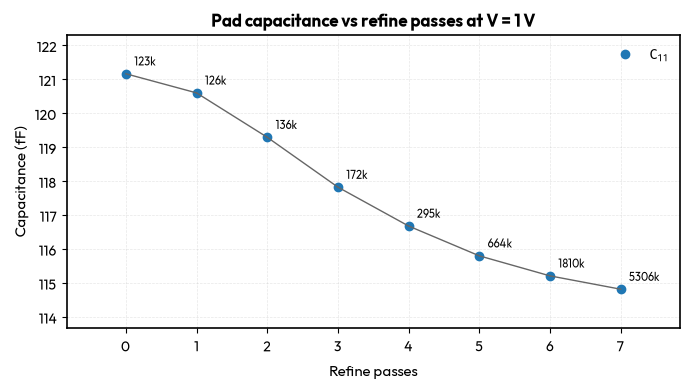

In [14]:
refine_file = result_file(MESH_JSON)

if refine_file is None:
    explain_missing_results(MESH_JSON)
else:
    refine_payload = json.loads(refine_file.read_text())
    refine_rows = refine_payload.get(LOCAL_MESH_KEY) or []
    refine_failures = refine_payload.get(f"{LOCAL_MESH_KEY}_failures") or []
    for failure in refine_failures:
        print(f"Refine passes {failure['refine_passes']} failed: {failure['error']}")
    if not refine_rows:
        explain_missing_results(MESH_JSON)
        print(f"The file on disk carries no {LOCAL_MESH_KEY} rows.")
    else:
        refine_rows = sorted(refine_rows, key=itemgetter("refine_passes"))
        passes = np.array([row["refine_passes"] for row in refine_rows], dtype=int)
        element_counts = np.array(
            [row["element_count"] for row in refine_rows], dtype=float
        )
        capacitance_ff = (
            np.array([row["c11_f"] for row in refine_rows], dtype=float) * 1e15
        )
        energy_ff = (
            np.array([row["int_we_j"] for row in refine_rows], dtype=float)
            * 2.0
            / np.array([row["voltage_v"] for row in refine_rows], dtype=float) ** 2
            * 1e15
        )
        voltages_v = {float(row["voltage_v"]) for row in refine_rows}
        if len(voltages_v) != 1:
            raise ValueError("Refinement rows have different solved voltages")
        solved_voltage_v = voltages_v.pop()

        print(
            f"{'pass':>4} {'elements':>10} {'C11 (fF)':>10} {'dC11':>9} "
            f"{'2W/V^2 (fF)':>12} {'rel. diff':>10}"
        )
        for index, row in enumerate(refine_rows):
            consecutive = index > 0 and passes[index] == passes[index - 1] + 1
            step = (
                f"{capacitance_ff[index] - capacitance_ff[index - 1]:>+9.4f}"
                if consecutive
                else ""
            )
            relative = (
                abs(energy_ff[index] - capacitance_ff[index]) / capacitance_ff[index]
            )
            print(
                f"{row['refine_passes']:>4} {row['element_count']:>10} "
                f"{capacitance_ff[index]:>10.4f} {step:>9} "
                f"{energy_ff[index]:>12.4f} {relative:>10.1e}"
            )

        if len(refine_rows) >= 2 and passes[-1] == passes[-2] + 1:
            last_change = abs(capacitance_ff[-1] - capacitance_ff[-2])
            relative_change = last_change / abs(capacitance_ff[-1])
            print(
                "Last consecutive-pass change in C11: "
                f"{last_change:.4f} fF ({relative_change:.3%}); "
                f"below 0.5%: {relative_change < 0.005}"
            )

        present_passes = set(passes)
        missing_passes = [
            number
            for number in range(int(passes.min()), int(passes.max()) + 1)
            if number not in present_passes
        ]
        if missing_passes:
            missing = ", ".join(str(number) for number in missing_passes)
            print(f"No row for refine passes: {missing}")

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(
            passes,
            capacitance_ff,
            linestyle="none",
            marker="o",
            markersize=6,
            label=r"$C_{11}$",
        )
        for index in range(passes.size - 1):
            if passes[index + 1] == passes[index] + 1:
                ax.plot(
                    passes[index : index + 2],
                    capacitance_ff[index : index + 2],
                    color="0.4",
                    linewidth=1.0,
                )
        for x, y, count in zip(passes, capacitance_ff, element_counts, strict=True):
            ax.annotate(
                compact_element_count(int(count)),
                (x, y),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=8,
            )
        ax.set_xticks(range(int(passes.min()), int(passes.max()) + 1))
        ax.margins(x=0.12, y=0.18)
        ax.set_xlabel("Refine passes")
        ax.set_ylabel("Capacitance (fF)")
        ax.set_title(f"Pad capacitance vs refine passes at V = {solved_voltage_v:g} V")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

### Field on the locally refined mesh

This potential and field map comes from the last refinement pass above. The
pad capacitance is more stable there than on the automatic size 1 mesh, but
the pointwise maximum at a sharp metal edge remains mesh sensitive.

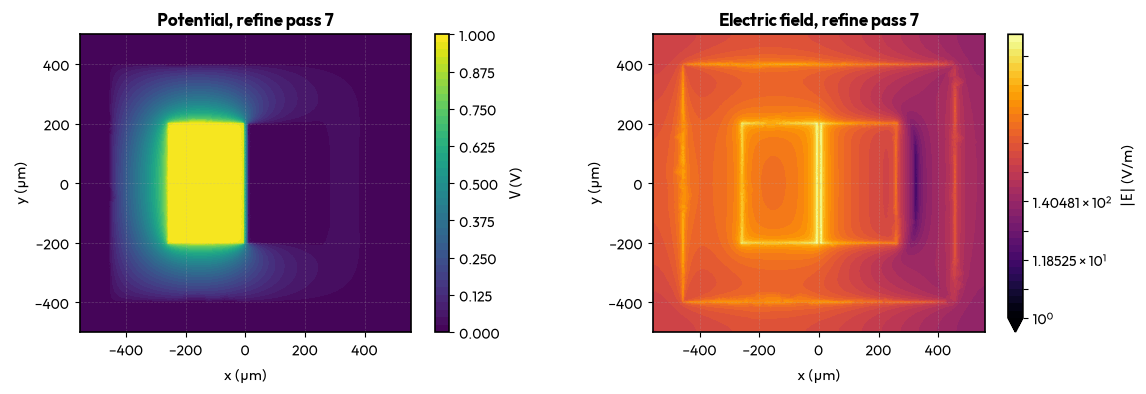

In [15]:
refined_field_file = result_file("comsol_qubit_refined_field.txt")
refined_field_meta_file = result_file("comsol_qubit_refined_field.json")
refined_mesh_file = result_file(MESH_JSON)
if (
    refined_field_file is None
    or refined_field_meta_file is None
    or refined_mesh_file is None
):
    explain_missing_results("comsol_qubit_refined_field.txt")
else:
    field_meta = json.loads(refined_field_meta_file.read_text())
    field_pass = int(field_meta["refine_passes"])
    matching_rows = [
        row
        for row in json.loads(refined_mesh_file.read_text()).get(LOCAL_MESH_KEY, [])
        if row["refine_passes"] == field_pass
    ]
    if (
        len(matching_rows) != 1
        or matching_rows[0]["element_count"] != field_meta["element_count"]
    ):
        raise ValueError("Refined field metadata does not match a solved mesh row")
    refined_field = np.loadtxt(refined_field_file, comments="%")
    field_x, field_y = refined_field[:, 0], refined_field[:, 1]
    field_v, field_e = refined_field[:, 3], refined_field[:, 4]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    potential = axes[0].tricontourf(
        field_x, field_y, field_v, levels=40, cmap="viridis"
    )
    axes[0].set_title(f"Potential, refine pass {field_pass}")
    fig.colorbar(potential, ax=axes[0], label=r"$V$ (V)")
    norm_e = axes[1].tricontourf(
        field_x,
        field_y,
        field_e,
        levels=np.geomspace(1.0, field_e.max(), 40),
        norm=LogNorm(vmin=1.0, vmax=field_e.max()),
        cmap="inferno",
        extend="min",
    )
    axes[1].set_title(f"Electric field, refine pass {field_pass}")
    fig.colorbar(norm_e, ax=axes[1], label=r"$|\mathbf{E}|$ (V/m)")
    for axis in axes:
        axis.set_aspect("equal")
        axis.set_xlabel("x (µm)")
        axis.set_ylabel("y (µm)")
    plt.tight_layout()
    plt.show()

## Summary

1. Built a QPDK `double_pad_transmon_with_bbox` cell and made an EM-only copy
   with `JJ_AREA`/`JJ_PATCH` removed, so the SQUID and its leads are not in the
   solved geometry.
2. Extracted the two pad polygons and the ground plane with
   `prepare_comsol_layout(..., feed_ports=None)`.
3. Built the COMSOL sheet model and added an Electrostatics study: a voltage
   terminal on the left pad, ground on the right pad and the ground plane, a
   mesh, and a stationary study.
4. Exported `es.C11` and `es.intWe`, checked them against each other through
   $2 W_e / V^2$, and replotted the exported potential and field map.
5. Plotted the separately solved mesh series over seven automatic sizes. A
   settled $C_{11}$ would not establish convergence of the peak field or the
   domain boundary effect.
6. Plotted a second series with localized refinement near the metal plane.
   Each series has its own mesh control and must be interpreted separately.

### Limitations

- The solve is electrostatic; the metal is a perfect conductor and there is no
  Josephson inductance, so no resonance is solved.
- The `f_LC` number uses a chosen $L_J$ and $C_{11}$ in place of a two-pad
  differential capacitance. It is not a transmon eigenfrequency or $f_{01}$.
- The EM-only copy omits the SQUID loop and its leads, so their parasitic
  capacitance is missing from $C_{11}$.
- The main capacitance and field map use one mesh setting; the saved
  convergence plots are from separate solves.

### Next steps

- Extract the two-pad capacitance matrix, then use its differential-mode
  capacitance with a junction model in the QPDK Hamiltonian workflow
  ({doc}`/notebooks/scqubits_parameter_calculation`).
- Refine the mesh at the pad gap and the metal edges and confirm $C_{11}$
  stops moving.

## References

```{bibliography}
:filter: docname in docnames
```